In [16]:
import chipwhisperer as cw
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA
from scipy import stats
import sys
import seaborn as sns
import scipy.signal
sys.path.append("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/")
from privacy_amplification.FFT.FFT import *
import TA_tools
import importlib
importlib.reload(TA_tools)

SCOPETYPE = 'OPENADC'
PLATFORM = 'CW308_SAM4S'
SS_VER = 'SS_VER_2_1'

In [17]:
%run "/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/adversary/TA_segmented_initialise.ipynb"

INFO: Caught exception on reconnecting to target - attempting to reconnect to scope first.
INFO: This is a work-around when USB has died without Python knowing. Ignore errors above this line.
INFO: Found ChipWhisperer😍
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7370129.87012987         
scope.clock.adc_freq                     changed from 0                         to 29480519.48051948        
scope.clock.extclk_monitor_enabled       changed from True                      to False                    
scope.clock.extclk

In [18]:
tools = TA_tools.Tools(scope,target)
N=16
seg_count = int((N/2)*np.log2(N))

In [19]:
sigma = [0,1,2,3,4,5,6,7,8,9,10]
repeats = 3
L = 3
rec_rate = []
for sig in sigma:
    results = []
    for r in range(repeats):
        results.append(tools.run_attack(L,sig,N,seg_count))
    rec_rate.append(np.asarray(results).mean(axis=0)/N)

[0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 1]


Segment 0
Guess 0. MSE: 0.00019201793436042855, PC: PearsonRResult(statistic=0.9965270641010826, pvalue=0.0)
Guess 1. MSE: 0.036403543054936066, PC: PearsonRResult(statistic=0.3410795574608387, pvalue=1.385052468994474e-82)
Guess 2. MSE: 0.021337032969568317, PC: PearsonRResult(statistic=0.6156322171452804, pvalue=2.082538505626e-312)
Guess 3. MSE: 0.02754414153564573, PC: PearsonRResult(statistic=0.5030727836597968, pvalue=3.637355563292434e-192)


Segment 1
Guess 0. MSE: 0.027255621219122117, PC: PearsonRResult(statistic=0.5094278562353712, pvalue=8.40735653121787e-198)
Guess 1. MSE: 0.00018066002649418412, PC: PearsonRResult(statistic=0.9967450789093697, pvalue=0.0)
Guess 2. MSE: 0.04428755679209523, PC: PearsonRResult(statistic=0.1998221222116184, pvalue=2.1935894199675583e-28)
Guess 3. MSE: 0.03306802908623675, PC: PearsonRResult(statistic=0.40276566151835824, pvalue=2.332988562926578e-117)


Segment 2
Guess 0. MSE: 0.00019092574786832493, PC: P

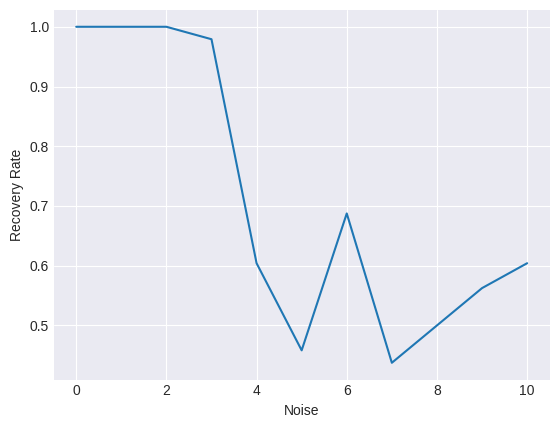

In [20]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(sigma,rec_rate)
plt.xlabel("Noise")
plt.ylabel("Recovery Rate")
plt.show()

Section where we aim to show the difference between each of the four hypothesis inputs.

In [30]:
x1 = "0000000000000000\n"
x2 = "0000000010000000\n"
x3 = "1000000000000000\n"
x4 = "1000000010000000\n"

x1_avg = []
x2_avg = []
x3_avg = []
x4_avg = []

for _ in range(10):
    x1_avg.append(tools.get_trace(x1)[0])
    x2_avg.append(tools.get_trace(x2)[0])
    x3_avg.append(tools.get_trace(x3)[0])
    x4_avg.append(tools.get_trace(x4)[0])

x1_avg = np.asarray(x1_avg).mean(axis=0)
x2_avg = np.asarray(x2_avg).mean(axis=0)
x3_avg = np.asarray(x3_avg).mean(axis=0)
x4_avg = np.asarray(x4_avg).mean(axis=0)


tools.plot_overlay([x1_avg, x2_avg, x3, x3_avg, x4_avg])


DataError: Following columns specified as dimensions but not found in data: ['y']

DictInterface expects tabular data, for more information on supported datatypes see https://holoviews.org/user_guide/Tabular_Datasets.html